# Decision Tree Classification: Gini vs Cross Entropy

This notebook compares **Gini impurity** and **Cross Entropy (Entropy)** as splitting criteria
for Decision Trees on a single dataset.

Evaluation metrics used:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Cross Validation Accuracy


## 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

## 2. Load Dataset

In [5]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print('Dataset shape:', X.shape)
X.head()

Dataset shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Train Decision Tree with Gini

In [7]:
gini_model = DecisionTreeClassifier(criterion='gini', random_state=42)
gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)

## 5. Train Decision Tree with Entropy

In [8]:
entropy_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

## 6. Evaluation Metrics

In [9]:
def evaluate(y_true, y_pred, name):
    print('---', name, '---')
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Precision:', precision_score(y_true, y_pred))
    print('Recall:', recall_score(y_true, y_pred))
    print('F1 Score:', f1_score(y_true, y_pred))
    print('Confusion Matrix:\n', confusion_matrix(y_true, y_pred))
    print('\n')

evaluate(y_test, gini_pred, 'Gini Tree')
evaluate(y_test, entropy_pred, 'Entropy Tree')

--- Gini Tree ---
Accuracy: 0.9473684210526315
Precision: 0.9577464788732394
Recall: 0.9577464788732394
F1 Score: 0.9577464788732394
Confusion Matrix:
 [[40  3]
 [ 3 68]]


--- Entropy Tree ---
Accuracy: 0.9473684210526315
Precision: 0.9333333333333333
Recall: 0.9859154929577465
F1 Score: 0.958904109589041
Confusion Matrix:
 [[38  5]
 [ 1 70]]




## 7. Cross Validation Comparison

In [10]:
gini_cv = cross_val_score(DecisionTreeClassifier(criterion='gini'), X, y, cv=5)
entropy_cv = cross_val_score(DecisionTreeClassifier(criterion='entropy'), X, y, cv=5)

print('Gini CV Mean Accuracy:', gini_cv.mean())
print('Entropy CV Mean Accuracy:', entropy_cv.mean())

Gini CV Mean Accuracy: 0.9191119391398852
Entropy CV Mean Accuracy: 0.9402577239559076


## 8. Visual Comparison

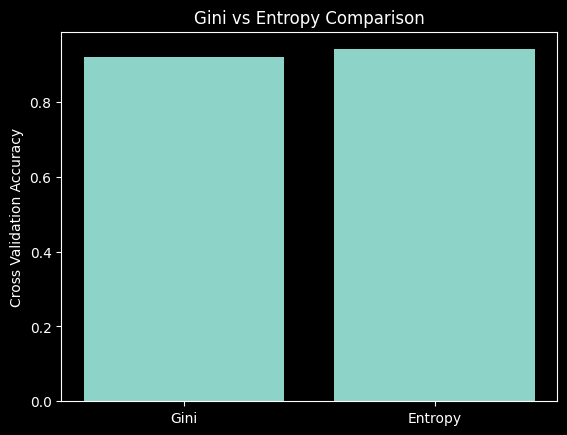

In [11]:
scores = [gini_cv.mean(), entropy_cv.mean()]
labels = ['Gini', 'Entropy']

plt.bar(labels, scores)
plt.ylabel('Cross Validation Accuracy')
plt.title('Gini vs Entropy Comparison')
plt.show()

## 9. Conclusion

- Both criteria produce very similar performance.
- Gini is slightly faster computationally.
- Entropy may create slightly more informative splits.
- In most practical tasks the difference is very small.